In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [75]:
#importing data from csv file
data = pd.read_csv("good_doctor_data.csv")

#Data Cleaning and Preprocessing

In [76]:
#deleting rows with NaN values and set ID as a string type
data.dropna(inplace = True)
data.reset_index(drop = True, inplace = True)
data['Unique_ID'] = data['Unique_ID'].astype(int)
data['Unique_ID'] = data['Unique_ID'].astype(str)

In [77]:
#renaming data to better understanding and quicker usage
data.rename(columns = {'Unique_ID': 'ID', 'Blood Chemestry~I': 'BC I', 'Blood Chemisty~II': 'BC II', 'Blood Chemisty~III': 'BC III',
            'Skin Thickness': 'Skin Condition', 'Genetic Predisposition Factor': 'GPF', '''Air Qual'ty Index''': 'Air Quality Index', '$tate': 'State'}, inplace = True)
data

,ID,# Pregnancies,BC I,BC II,BC III,Blood Pressure,Skin Condition,BMI,GPF,Age,Air Quality Index,State,Outcome
0,5642118,1.0,0.0,23.0,10.0,74.0,20.0,27.7,0.299,21.0,38.0,CA,0.0
1,5642119,1.0,0.0,0.0,61.0,68.0,35.0,32.0,0.389,22.0,10.0,CA,0.0
2,5642120,1.0,0.0,0.0,172.0,48.0,20.0,24.7,0.140,22.0,77.0,CA,0.0
3,5642121,5.0,44.0,0.0,207.0,62.0,0.0,25.0,0.587,36.0,40.0,OR,0.0
4,5642122,2.0,56.0,45.0,150.0,56.0,28.0,24.2,0.332,22.0,70.0,CT,0.0
5,5642123,9.0,57.0,0.0,334.0,80.0,37.0,32.8,0.096,41.0,64.0,UT,0.0
6,5642124,0.0,57.0,0.0,217.0,60.0,0.0,21.7,0.735,67.0,70.0,UT,0.0
7,5642125,3.0,61.0,0.0,335.0,82.0,28.0,34.4,0.243,46.0,76.0,WV,0.0
8,5642126,7.0,62.0,0.0,306.0,78.0,0.0,32.6,0.391,41.0,4.0,TN,0.0
9,5642127,8.0,65.0,0.0,145.0,72.0,23.0,32.0,0.600,42.0,47.0,VA,0.0


In [78]:
#notice that we have some misspelling values such as 'KU'
data[(data['State'] == 'KU') | (data['State'] == 'KY')]

,ID,# Pregnancies,BC I,BC II,BC III,Blood Pressure,Skin Condition,BMI,GPF,Age,Air Quality Index,State,Outcome
12,5642130,2.0,68.0,66.0,49.0,70.0,32.0,25.0,0.187,25.0,0.0,KY,0.0
45,5642163,2.0,81.0,76.0,67.0,72.0,15.0,30.1,0.547,25.0,2.0,KY,0.0
101,5642219,1.0,90.0,59.0,89.0,62.0,18.0,25.1,1.268,25.0,90.0,KY,0.0
116,5642234,1.0,92.0,41.0,14.0,62.0,25.0,19.5,0.482,25.0,36.0,KY,0.0
139,5642257,1.0,95.0,38.0,53.0,66.0,13.0,19.6,0.334,25.0,52.0,KY,0.0
214,5642333,6.0,103.0,190.0,269.0,72.0,32.0,37.7,0.324,55.0,31.0,KY,0.0
288,5642407,1.0,112.0,176.0,316.0,72.0,30.0,34.4,0.528,25.0,60.0,KY,0.0
311,5642431,1.0,116.0,180.0,257.0,78.0,29.0,36.1,0.496,25.0,60.0,KY,0.0
512,5642638,10.0,101.0,0.0,60.0,86.0,37.0,45.6,1.136,38.0,78.0,KU,1.0
531,5642657,5.0,109.0,129.0,318.0,62.0,41.0,35.8,0.514,25.0,92.0,KY,1.0


In [79]:
#changing KU records to KY records
data.loc[data['State'] == 'KU', 'State'] = 'KY'

In [80]:
#here we can notice outliers in some columns
data.describe()

,# Pregnancies,BC I,BC II,BC III,Blood Pressure,Skin Condition,BMI,GPF,Age,Air Quality Index,Outcome
count,3785.000000,3785.000000,3785.000000,3785.000000,3785.000000,3785.000000,3785.000000,3785.000000,3785.000000,3785.000000,3785.000000
mean,3.859974,120.819022,80.104359,174.414267,69.243065,20.644650,32.017041,0.472028,33.557464,49.084544,0.350066
std,3.353936,32.021816,115.651333,100.904069,19.145159,15.974404,7.899997,0.332080,13.761347,29.151736,0.477053
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000,0.000000
25%,1.000000,99.000000,0.000000,88.000000,62.000000,0.000000,27.300000,0.243000,24.000000,24.000000,0.000000
50%,3.000000,117.000000,32.000000,175.000000,72.000000,23.000000,32.000000,0.371000,29.000000,49.000000,0.000000
75%,6.000000,141.000000,127.000000,259.000000,80.000000,32.000000,36.600000,0.626000,41.000000,72.000000,1.000000
max,17.000000,199.000000,846.000000,350.000000,122.000000,99.000000,67.100000,2.420000,230.000000,100.000000,1.000000


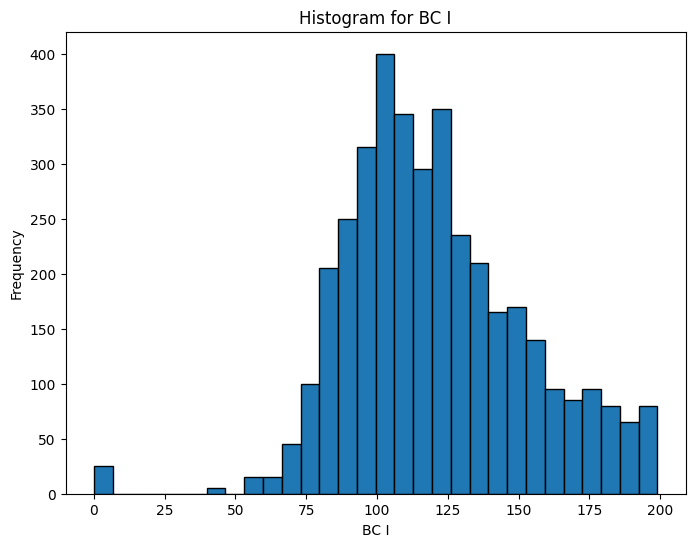

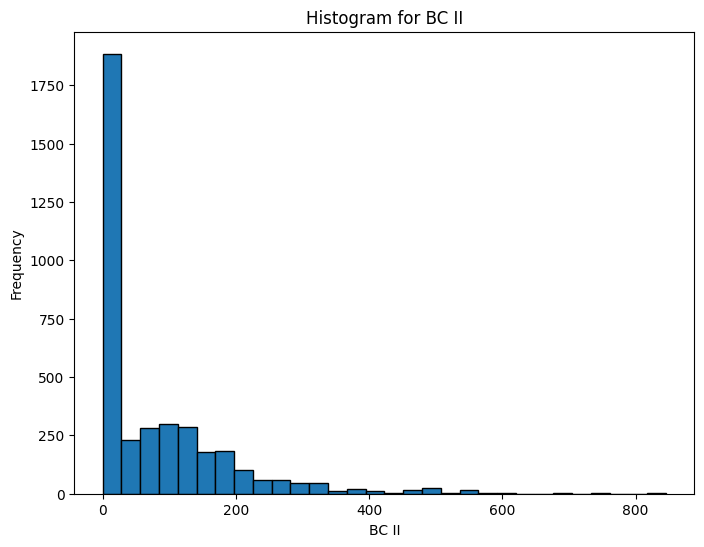

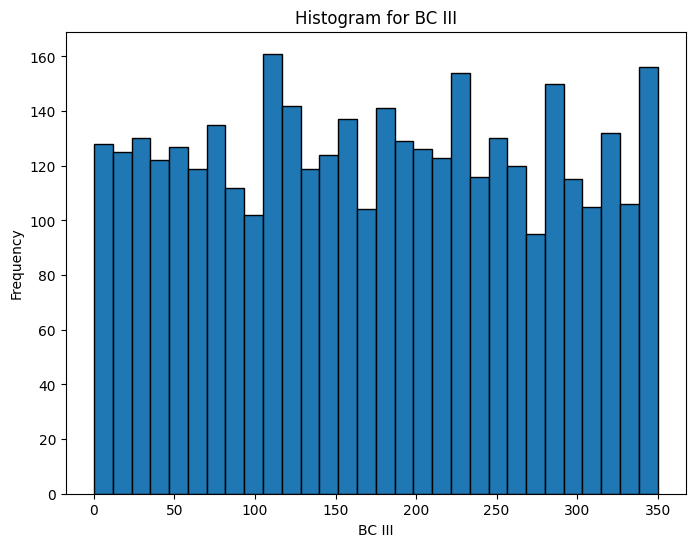

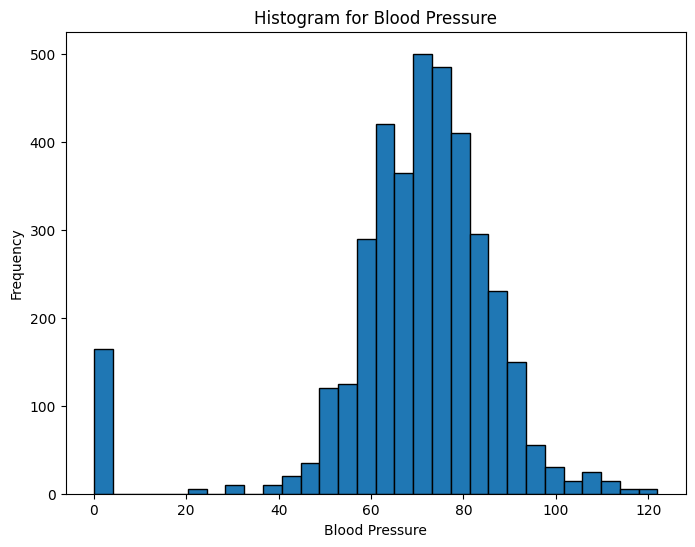

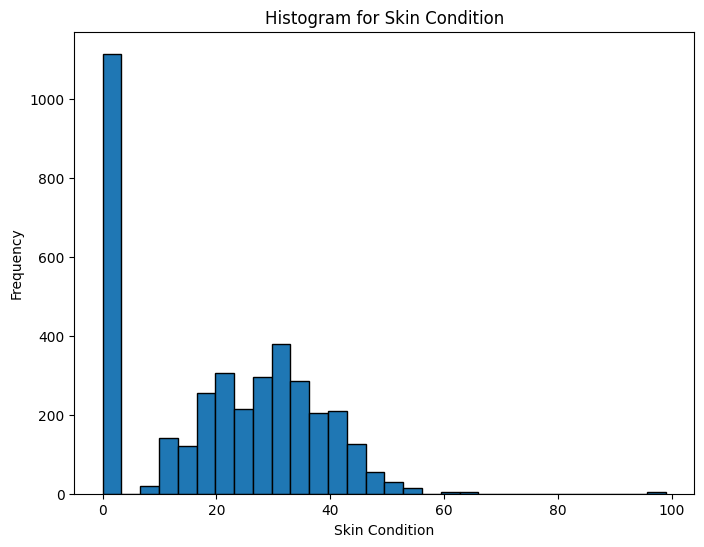

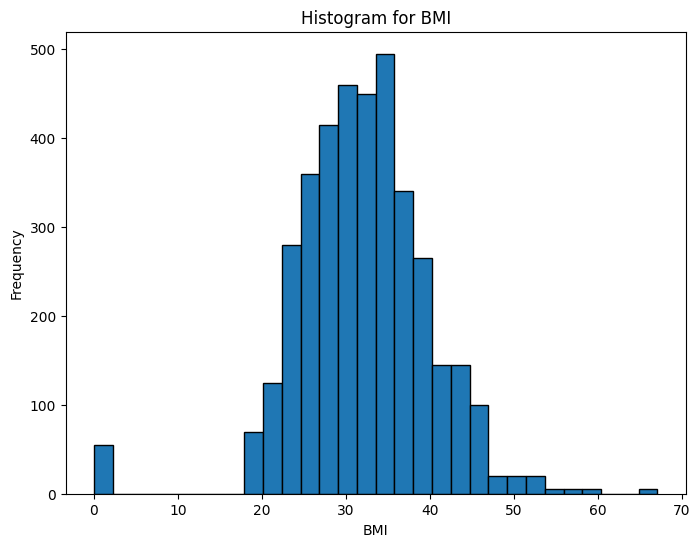

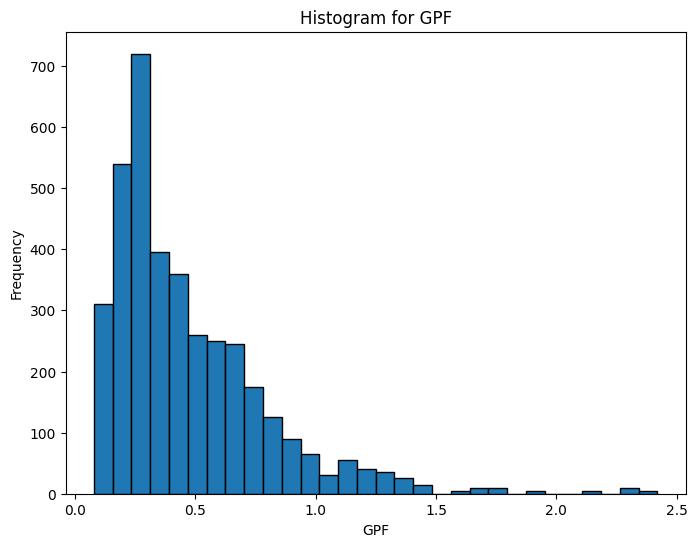

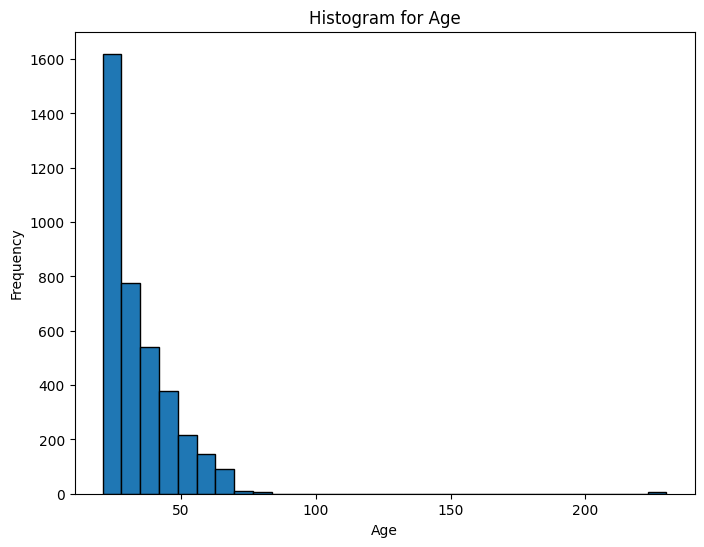

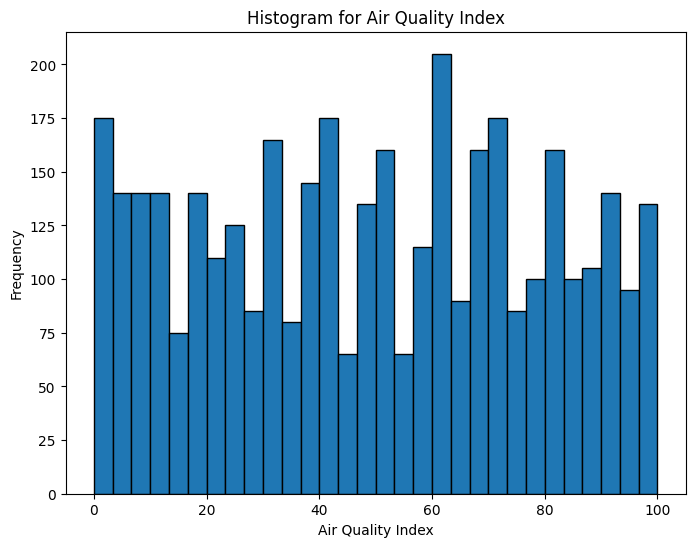

In [81]:
for column in data.columns[2:11]:
    plt.figure(figsize=(8, 6))
    plt.hist(data[column], bins=30, edgecolor='black')
    plt.title(f'Histogram for {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

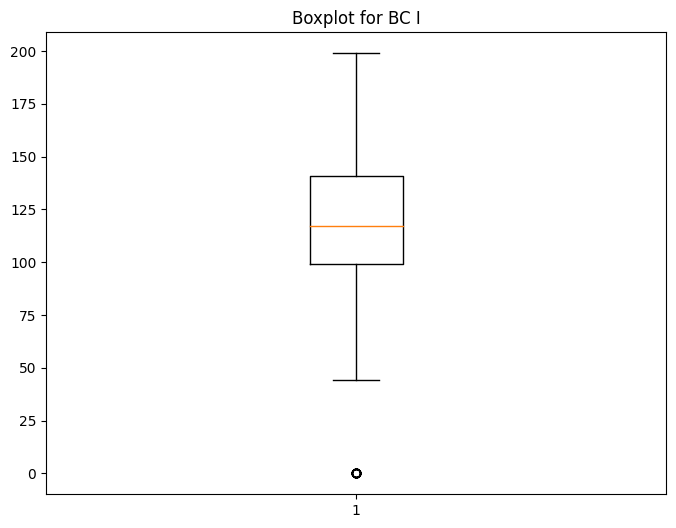

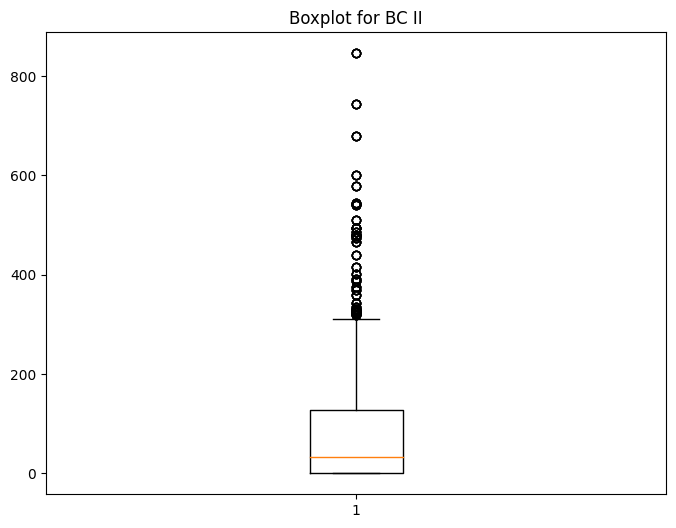

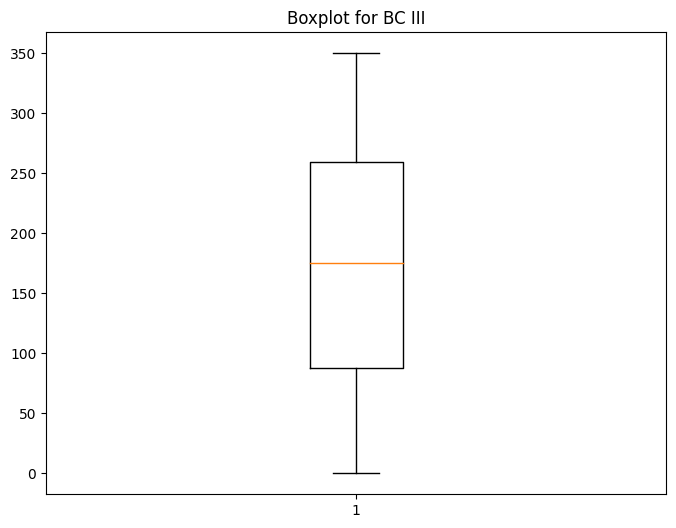

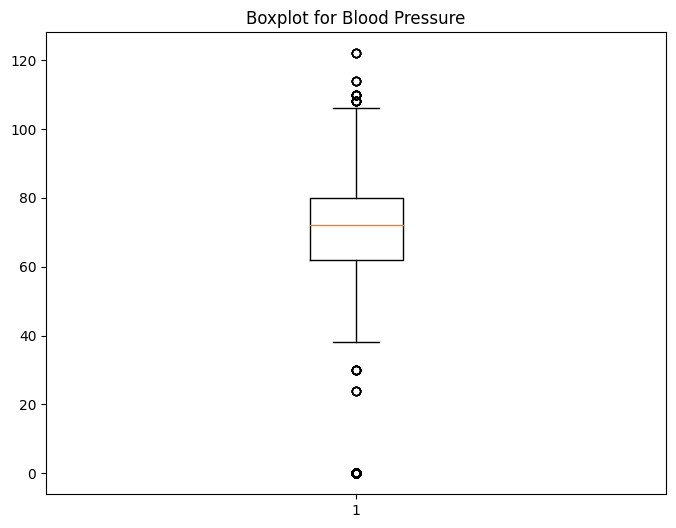

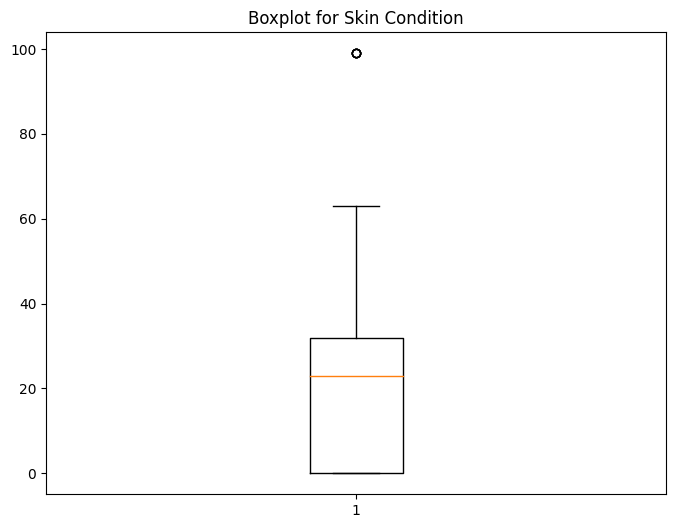

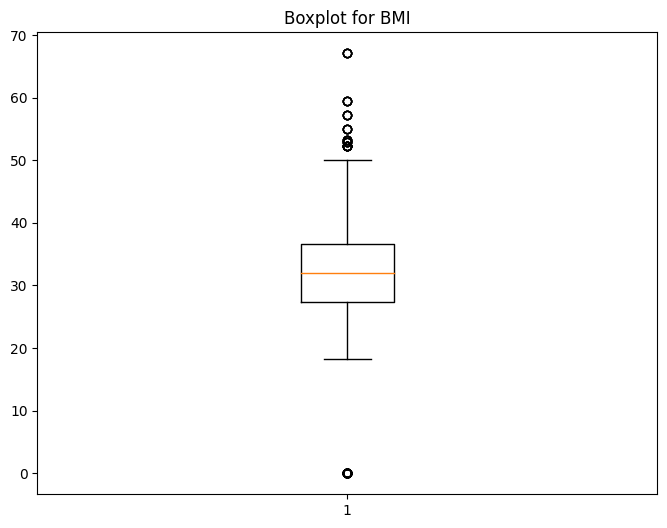

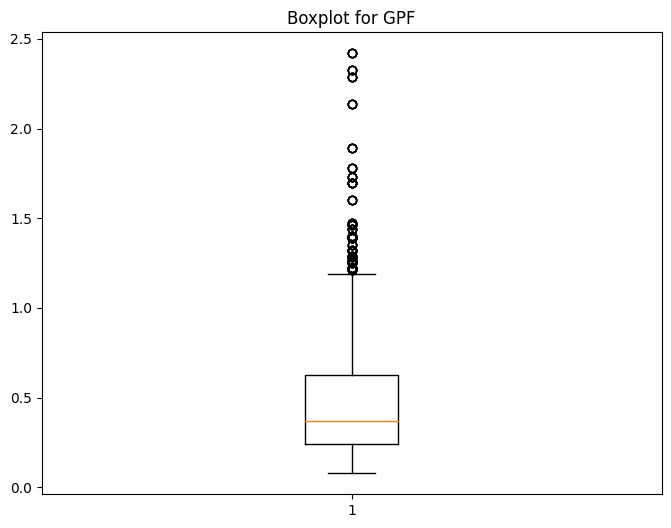

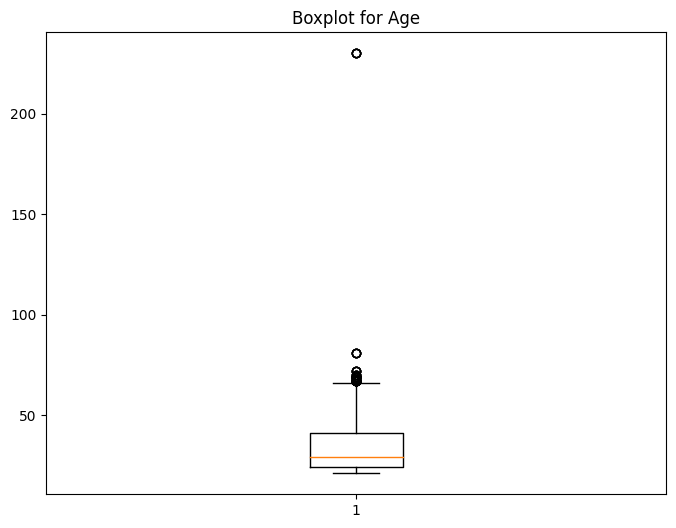

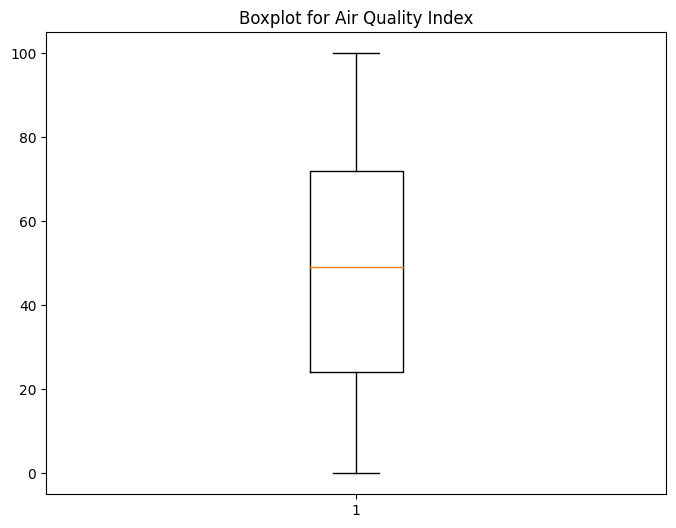

In [82]:
for column in data.columns[2:11]:
    plt.figure(figsize=(8, 6))
    plt.boxplot(data[column])
    plt.title(f'Boxplot for {column}')
    plt.show()

##Dealing with outliers

In [83]:
#replacing outliers for Blood Pressure to mean depending on outcome
BP0_mean = data[data['Outcome'] == 0]['Blood Pressure'].mean()
BP1_mean = data[data['Outcome'] == 1]['Blood Pressure'].mean()

data.loc[(data['Blood Pressure'] < 30) & (data['Outcome'] == 0), 'Blood Pressure'] = BP0_mean
data.loc[(data['Blood Pressure'] < 30) & (data['Outcome'] == 1), 'Blood Pressure'] = BP1_mean

In [84]:
#replacing outliers for BMI to mean depending on outcome
BMI0_mean = data[data['Outcome'] == 0]['BMI'].mean()
BMI1_mean = data[data['Outcome'] == 1]['BMI'].mean()

data.loc[((data['BMI'] < 15) | (data['BMI'] > 55)) & (data['Outcome'] == 0), 'BMI'] = BMI0_mean
data.loc[((data['BMI'] < 15) | (data['BMI'] > 55)) & (data['Outcome'] == 1), 'BMI'] = BMI1_mean

In [85]:
#checking how many age's records are outliers
data[data['Age'] > 100]

,ID,# Pregnancies,BC I,BC II,BC III,Blood Pressure,Skin Condition,BMI,GPF,Age,Air Quality Index,State,Outcome
159,5642277,1.0,97.0,82.0,262.0,64.0,19.0,18.2,0.299,230.0,58.0,WI,0.0
916,5642277,1.0,97.0,82.0,158.0,64.0,19.0,18.2,0.299,230.0,58.0,WI,0.0
1673,5642277,1.0,97.0,82.0,55.0,64.0,19.0,18.2,0.299,230.0,58.0,WI,0.0
2430,5642277,1.0,97.0,82.0,205.0,64.0,19.0,18.2,0.299,230.0,58.0,WI,0.0
3187,5642277,1.0,97.0,82.0,307.0,64.0,19.0,18.2,0.299,230.0,58.0,WI,0.0


In [86]:
#deleting records with outlier age
data = data[data['Age'] < 100]
data.reset_index(drop = True, inplace = True)

In [87]:
#deleting ID column - it does not give us any value information
data = data.drop(columns = ['ID'])

In [88]:
#we have dealt with some outliers
data.describe()

,# Pregnancies,BC I,BC II,BC III,Blood Pressure,Skin Condition,BMI,GPF,Age,Air Quality Index,Outcome
count,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000
mean,3.863757,120.850529,80.101852,174.383862,72.345439,20.646825,32.379282,0.472257,33.297619,49.072751,0.350529
std,3.354539,32.031262,115.727797,100.917430,12.057181,15.984856,6.619298,0.332240,11.768587,29.169210,0.477199
min,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,18.200000,0.078000,21.000000,0.000000,0.000000
25%,1.000000,99.000000,0.000000,88.000000,64.000000,0.000000,27.600000,0.242500,24.000000,24.000000,0.000000
50%,3.000000,117.000000,30.500000,175.000000,72.000000,23.000000,32.050000,0.372500,29.000000,49.000000,0.000000
75%,6.000000,141.000000,127.250000,259.000000,80.000000,32.000000,36.500000,0.626250,41.000000,72.250000,1.000000
max,17.000000,199.000000,846.000000,350.000000,122.000000,99.000000,55.000000,2.420000,81.000000,100.000000,1.000000


<Axes: xlabel='State'>

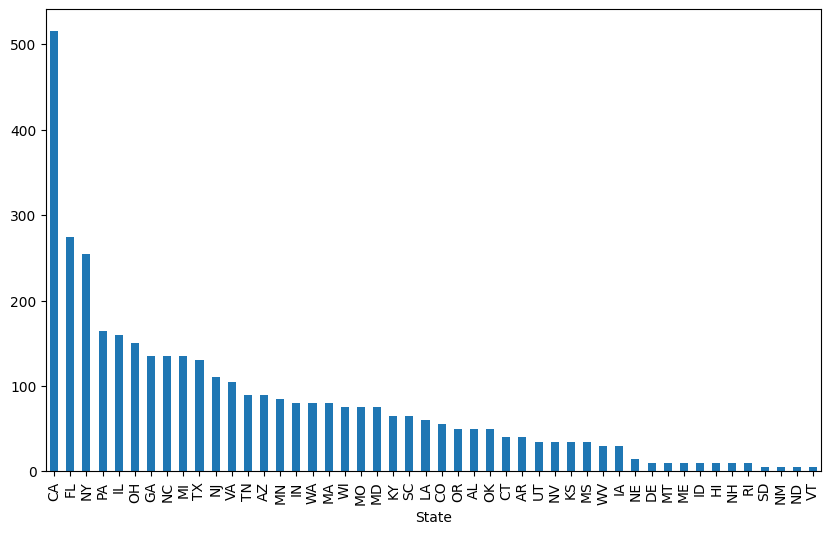

In [89]:
plt.figure(figsize=(10, 6))
data['State'].value_counts().plot(kind='bar')

## Encoding caterogical variable and normalizing data

In [90]:
#one-hot encoding method to convert categorical variable STATE to numerical format
data = pd.get_dummies(data, columns=['State'], drop_first=True)

In [91]:
#normalizing the data
scaler = MinMaxScaler()
norm_data = scaler.fit_transform(data)
data_scaled = pd.DataFrame(norm_data, columns=data.columns)

#Exploratory Data Analysis

In [92]:
#here we can see dispersion of all variables in one scale - it gives us more information about variables between each other
data_scaled.describe()

,# Pregnancies,BC I,BC II,BC III,Blood Pressure,Skin Condition,BMI,GPF,Age,Air Quality Index,Outcome,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DE,State_FL,State_GA,State_HI,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_ME,State_MI,State_MN,State_MO,State_MS,State_MT,State_NC,State_ND,State_NE,State_NH,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV
count,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.00000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000
mean,0.227280,0.607289,0.094683,0.498240,0.460277,0.208554,0.385307,0.168342,0.204960,0.490728,0.350529,0.010582,0.023810,0.136243,0.01455,0.010582,0.002646,0.072751,0.035714,0.002646,0.007937,0.002646,0.042328,0.021164,0.009259,0.017196,0.015873,0.021164,0.019841,0.002646,0.035714,0.022487,0.019841,0.009259,0.002646,0.035714,0.001323,0.003968,0.002646,0.029101,0.001323,0.009259,0.067460,0.039683,0.013228,0.013228,0.043651,0.002646,0.017196,0.001323,0.023810,0.034392,0.009259,0.027778,0.001323,0.021164,0.019841,0.007937
std,0.197326,0.160961,0.136794,0.288336,0.131056,0.161463,0.179872,0.141862,0.196143,0.291692,0.477199,0.102337,0.152476,0.343092,0.11976,0.102337,0.051373,0.259762,0.185601,0.051373,0.088745,0.051373,0.201363,0.143950,0.095791,0.130017,0.125001,0.143950,0.139473,0.051373,0.185601,0.148280,0.139473,0.095791,0.051373,0.185601,0.036350,0.062877,0.051373,0.168111,0.036350,0.095791,0.250851,0.195238,0.114263,0.114263,0.204344,0.051373,0.130017,0.036350,0.152476,0.182257,0.095791,0.164357,0.036350,0.143950,0.139473,0.088745
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.058824,0.497487,0.000000,0.251429,0.369565,0.000000,0.255435,0.070239,0.050000,0.240000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.176471,0.587940,0.036052,0.500000,0.456522,0.232323,0.376359,0.125747,0.133333,0.490000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.352941,0.708543,0.150414,0.740000,0.543478,0.323232,0.497283,0.234095,0.333333,0.722500,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.

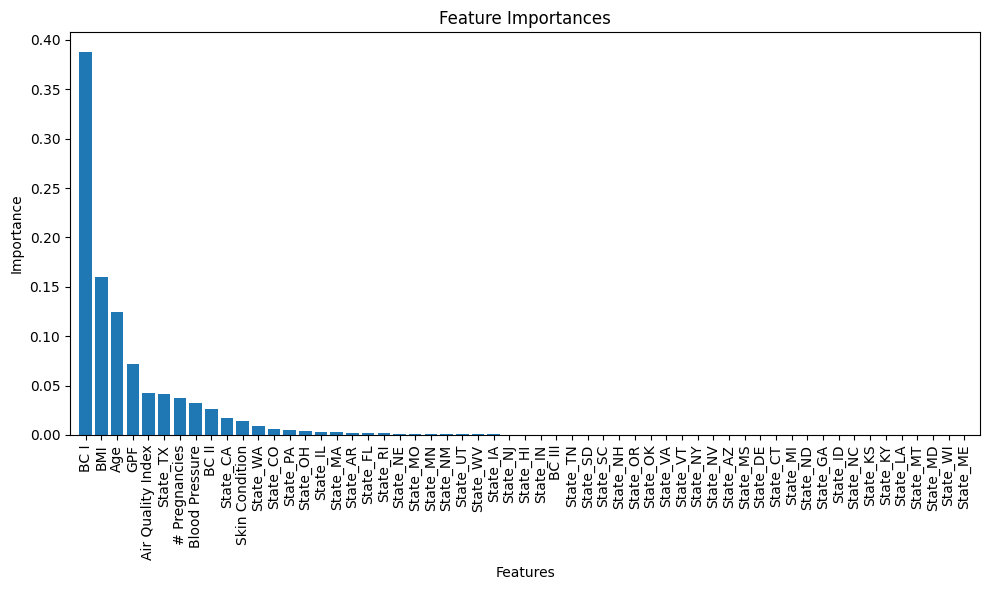

In [93]:
#our dataset consist 57 explanatory variables so we apply feature selection to select most influence variables
X_data = data_scaled.drop(columns= ['Outcome'])

clf = GradientBoostingClassifier()
clf.fit(X_data, data_scaled['Outcome'])
importances = clf.feature_importances_ # to get feature importances
indices = np.argsort(importances)[::-1] # sort in descending order

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_data.shape[1]), importances[indices], align="center")
plt.xticks(range(X_data.shape[1]), X_data.columns[indices], rotation=90)
plt.xlim([-1, X_data.shape[1]])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

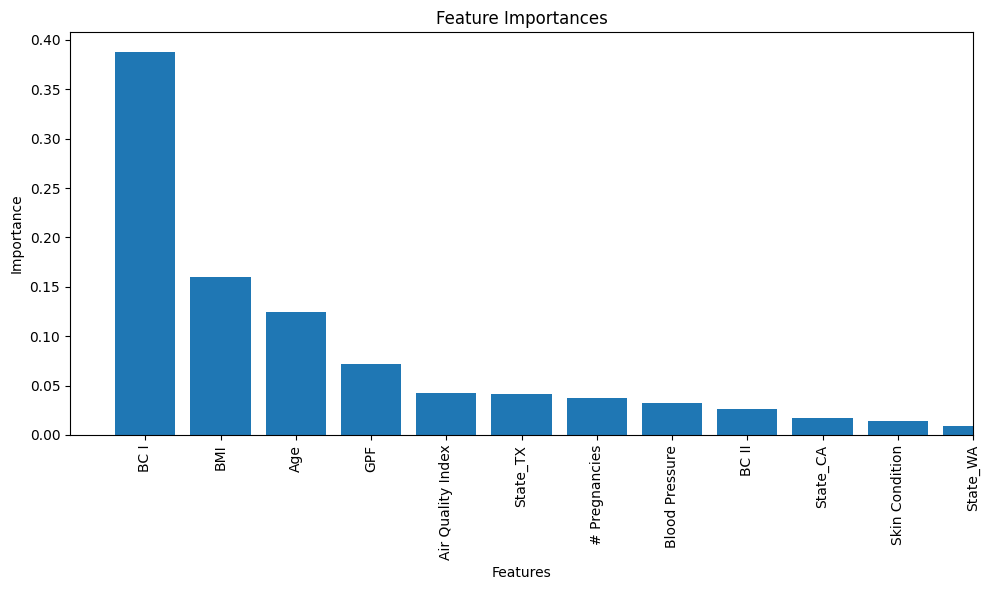

In [94]:
# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_data.shape[1]), importances[indices], align="center")
plt.xticks(range(X_data.shape[1]), X_data.columns[indices], rotation=90)
plt.xlim([-1, 11])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

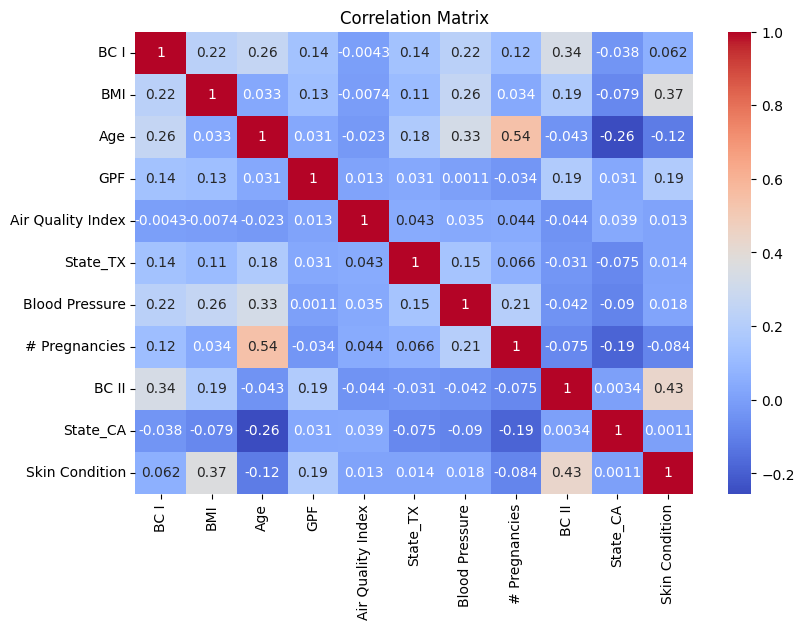

In [95]:
corr_matrix = data_scaled[['BC I', 'BMI', 'Age', 'GPF', 'Air Quality Index', 'State_TX', 'Blood Pressure', '# Pregnancies', 'BC II', 'State_CA', 'Skin Condition']].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [98]:
print("Average age in CA:", data[data['State_CA'] == 1]['Age'].mean())
print("Average age in other states:", data[data['State_CA'] == 0]['Age'].mean())

print("Average age in TX :", data[data['State_TX'] == 1]['Age'].mean())
print("Average age in other states:", data[data['State_TX'] == 0]['Age'].mean())

print("Number of records from TX:", data[data['State_TX'] == 1].shape[0])
print("Number of records from TX with disease:", data[data['State_TX'] == 1]['Outcome'].sum())

Average age in CA: 25.737864077669904
Average age in other states: 34.49004594180705
Average age in TX : 44.80769230769231
Average age in other states: 32.88767123287671
Number of records from TX: 130
Number of records from TX with disease: 125.0


#Predictive Modeling and Evaluation

##Logistic Regression

In [23]:
#Logistic regression
X_data = data_scaled.drop(columns= ['Outcome'])
X_train, X_test, y_train, y_test = train_test_split(X_data, data_scaled['Outcome'], test_size=0.2, random_state=10)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

<Figure size 600x600 with 0 Axes>

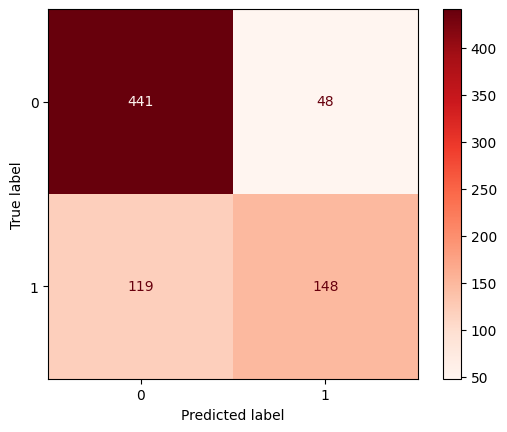

In [24]:
# Confusion matrix
plt.figure(figsize=(6, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.show()

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred)) # (TP + TN) / (TP + FP + FN + TN)
print("Precision:", precision_score(y_test, y_pred)) # TP / (TP + FP)
print("Recall:", recall_score(y_test, y_pred)) # TP / (TP + FN)

Accuracy: 0.7791005291005291
Precision: 0.7551020408163265
Recall: 0.5543071161048689


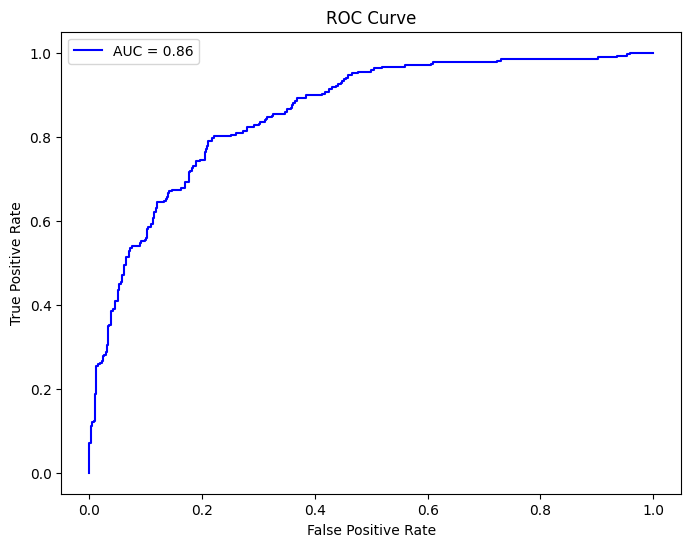

In [26]:
# ROC curve
# TPR = TP / (TP + FN)
# FPR = FP / (FP + TN)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

##Neural Networks

In [31]:
#Neural network with binary classification
NN_model = Sequential([
    Dense(12, activation='relu', input_shape=(X_train.shape[1],)), #input layer
    Dense(6, activation='relu'), #hidden
    Dense(1, activation='sigmoid')  # output, sigmoid function to predict binary classification
])
NN_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
NN_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
76/76 [==============================] - 2s 17ms/step - loss: 0.6570 - accuracy: 0.6308 - val_loss: 0.6536 - val_accuracy: 0.6231
Epoch 2/20
76/76 [==============================] - 0s 2ms/step - loss: 0.6273 - accuracy: 0.6569 - val_loss: 0.6420 - val_accuracy: 0.6231
Epoch 3/20
76/76 [==============================] - 0s 3ms/step - loss: 0.6104 - accuracy: 0.6569 - val_loss: 0.6268 - val_accuracy: 0.6231
Epoch 4/20
76/76 [==============================] - 0s 3ms/step - loss: 0.5918 - accuracy: 0.6569 - val_loss: 0.6109 - val_accuracy: 0.6231
Epoch 5/20
76/76 [==============================] - 0s 3ms/step - loss: 0.5734 - accuracy: 0.6569 - val_loss: 0.5939 - val_accuracy: 0.6231
Epoch 6/20
76/76 [==============================] - 0s 2ms/step - loss: 0.5533 - accuracy: 0.6569 - val_loss: 0.5754 - val_accuracy: 0.6231
Epoch 7/20
76/76 [==============================] - 0s 3ms/step - loss: 0.5345 - accuracy: 0.6916 - val_loss: 0.5616 - val_accuracy: 0.6926
Epoch 8/20
76/76 [=

In [32]:
y_pred_proba = NN_model.predict(X_test)
y_pred_NN = (y_pred_proba >= 0.5).astype(int)

24/24 [==============================] - 0s 1ms/step


<Figure size 600x600 with 0 Axes>

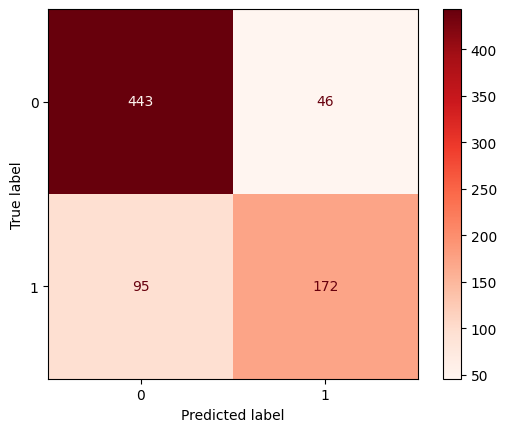

In [33]:
# Confusion matrix
plt.figure(figsize=(6, 6))
cm = confusion_matrix(y_test, y_pred_NN)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.show()

In [34]:
test_loss, test_accuracy = NN_model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy:}')

24/24 [==============================] - 0s 4ms/step - loss: 0.4348 - accuracy: 0.8135
Test accuracy: 0.8134920597076416
